In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr
from scipy.spatial.distance import euclidean, cdist

import sys

sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from skimage.filters import gaussian, median

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20251017_180538.log


In [2]:
# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
image_size = 16
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["variance"] = np.full((image_size, image_size), 1e-12)
camera_parameters["readnoise"] = np.full((image_size, image_size), 1e-12)
camera_parameters["rqe"] = np.full((image_size, image_size), 1.0)
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [3]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
dichroic_515_mirror = "semrock-di03-r514-t1-25x36"
nilered_filter = "semrock-ff01-650-200"
shortpass_filter = "semrock-bsp01-785r"
longpass_filter_515 = "semrock-ff01-515-lp"

filters = [nilered_filter, dichroic_515_mirror, longpass_filter_515]
filter_spectra = S_F.get_dye_or_filter_data(
    names=filters, wavelength=wavelength, dye_or_filter=False
)

In [4]:
dye = ["Nile Red"]

In [5]:
dye_spectrum = S_F.get_dye_or_filter_data(names=dye, wavelength=wavelength)
error = np.sqrt(dye_spectrum)

In [6]:
result, fitted_spectrum = S_F.spectral_fit_dye(dye_spectrum, wavelength, 
                                               model="skew-gaussian",
                                               weights=error,
                                               display=True)

In [7]:
result.x

array([  1.76625996e+02,   2.00736276e+00,   1.63010253e-01,
        -1.56453638e+00])

In [8]:
S_F.wavelength_to_energy(result.x[1])

617.64719764527081

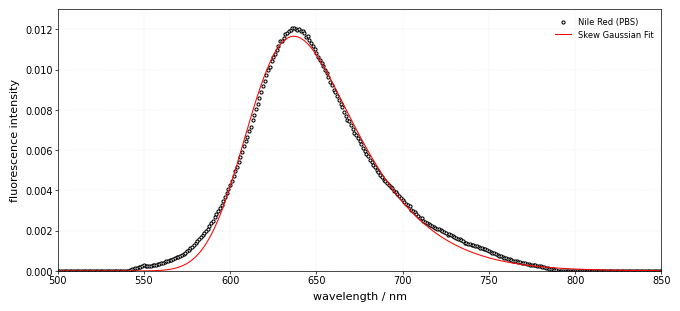

In [24]:
fig, axs = plotter.two_column_plot()

axs = plotter.scatter_plot(axs, x=wavelength, y=dye_spectrum.T, yaxislabel='fluorescence intensity', xaxislabel='wavelength / nm', 
                           label='Nile Red (PBS)')
axs = plotter.line_plot(axs, x=wavelength, y=fitted_spectrum, yaxislabel='fluorescence intensity', xaxislabel='wavelength / nm', color='red',
                       label='Skew Gaussian Fit')

axs.set_xlim([500, 850])
axs.set_ylim([0, 0.013])
axs.legend(loc='best', frameon=False, fontsize=6)
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20251023/fig/multicolour/Nile_Red/'
plt.savefig(os.path.join(folder, 'Fit_Fluo_Spectrum.svg'), dpi=600, format='svg')

In [10]:
S_F.wavelength_to_energy(result.x[1])

617.64719764527081

In [11]:
result.x[1:]

array([ 2.00736276,  0.16301025, -1.56453638])

In [12]:
# from https://www.sciencedirect.com/science/article/pii/0003269787901576
dielectric_constant = np.array([80, 64, 58, 44 ,37, 27, 34, 44, 24, 18, 11, 18, 38, 37, 21])
emission = np.array([665, 657, 655, 653, 652, 644, 642, 635, 635, 633, 633, 628, 627, 625, 615])

In [13]:
eV = S_F.wavelength_to_energy(emission)

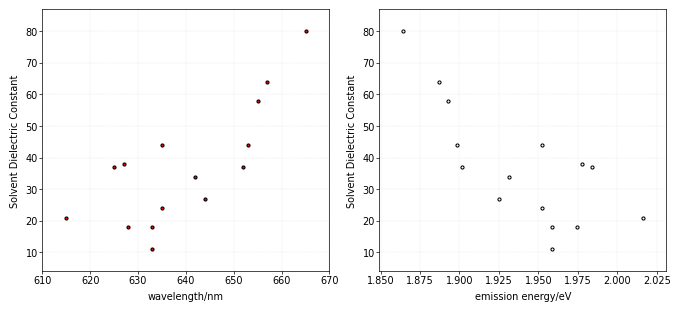

In [26]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

axs[1] = plotter.scatter_plot(axs[1], eV, dielectric_constant,
                          xaxislabel='emission energy/eV',
                          yaxislabel='Solvent Dielectric Constant')

axs[0] = plotter.scatter_plot(axs[0], emission, dielectric_constant, facecolor='red',
                          xaxislabel='wavelength/nm', yaxislabel='Solvent Dielectric Constant')

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Talks+Posters/Subgroup/20251023/fig/multicolour/Nile_Red/'
plt.savefig(os.path.join(folder, 'Nile_Red_Vs_Solvent.svg'), dpi=600, format='svg')

In [15]:
from src import NileRedFunctions

NR_F = NileRedFunctions.NileRed_Functions()

In [16]:
n_photon_space = np.logspace(np.log10(500), np.log10(20000), 25)

NR_F.simulate_wavelength_precision(
      save_folder="/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting",
      wavelength_range=(560, 620),
      wavelength_step=5,
      photon_counts=n_photon_space,
      filter_names=filters,
      n_bootstrap=10000,
      image_size = 16,
      background_photons = 40,
      camera_parameters=camera_parameters,
      verbose=False,
      use_tqdm=False,
  )

Sorting appended HDF5 file by frame: wl560_LM_method_simulated_NileRed_560nm_rawresults.h5                                                                                                                                                   ?, ?it/s]
  Read 20,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
Sorting appended HDF5 file by frame: wl560_LM_method_simulated_NileRed_560nm_rawresults.h5                                                                                                                                                   ?, ?it/s]
  Read 30,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
Sorting appended HDF5 file by frame: wl560_LM_method_simulated_NileRed_560nm_rawresults.h5                                                                                                                      

INFO:Multicolour_Simulation_Functions:Simulation completed for strategy standard


Sorting appended HDF5 file by frame: wl565_LM_method_simulated_NileRed_565nm_rawresults.h5                                                                                                                                                   ?, ?it/s]
  Read 20,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl565_LM_method_simulated_NileRed_565nm_rawresults.h5
Sorting appended HDF5 file by frame: wl565_LM_method_simulated_NileRed_565nm_rawresults.h5                                                                                                                                                   ?, ?it/s]
  Read 30,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl565_LM_method_simulated_NileRed_565nm_rawresults.h5
Sorting appended HDF5 file by frame: wl565_LM_method_simulated_NileRed_565nm_rawresults.h5                                                                                                                      

INFO:Multicolour_Simulation_Functions:Simulation completed for strategy standard


Sorting appended HDF5 file by frame: wl570_LM_method_simulated_NileRed_570nm_rawresults.h5                                                                                                                                                   ?, ?it/s]
  Read 20,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl570_LM_method_simulated_NileRed_570nm_rawresults.h5
Sorting appended HDF5 file by frame: wl570_LM_method_simulated_NileRed_570nm_rawresults.h5                                                                                                                                                   ?, ?it/s]
  Read 30,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl570_LM_method_simulated_NileRed_570nm_rawresults.h5
Sorting appended HDF5 file by frame: wl570_LM_method_simulated_NileRed_570nm_rawresults.h5                                                                                                                      

...

INFO:Multicolour_Simulation_Functions:Simulation completed for strategy standard


Sorting appended HDF5 file by frame: wl615_LM_method_simulated_NileRed_615nm_rawresults.h5                                                                                                                                                   ?, ?it/s]
  Read 20,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl615_LM_method_simulated_NileRed_615nm_rawresults.h5
Sorting appended HDF5 file by frame: wl615_LM_method_simulated_NileRed_615nm_rawresults.h5                                                                                                                                                   ?, ?it/s]
  Read 30,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl615_LM_method_simulated_NileRed_615nm_rawresults.h5
Sorting appended HDF5 file by frame: wl615_LM_method_simulated_NileRed_615nm_rawresults.h5                                                                                                                      

INFO:Multicolour_Simulation_Functions:Simulation completed for strategy standard


Sorting appended HDF5 file by frame: wl620_LM_method_simulated_NileRed_620nm_rawresults.h5                                                                                                                                                   ?, ?it/s]
  Read 20,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl620_LM_method_simulated_NileRed_620nm_rawresults.h5
Sorting appended HDF5 file by frame: wl620_LM_method_simulated_NileRed_620nm_rawresults.h5                                                                                                                                                   ?, ?it/s]
  Read 30,000 total localizations
  Sorted by frame (range: 0-9999)
  Rewritten sorted data to wl620_LM_method_simulated_NileRed_620nm_rawresults.h5
Sorting appended HDF5 file by frame: wl620_LM_method_simulated_NileRed_620nm_rawresults.h5                                                                                                                      

INFO:Multicolour_Simulation_Functions:Simulation completed for strategy standard


In [ ]:
folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20251007_NileRedModelTesting'
files_650 = H_F.file_search(folder, '.h5', 'wl585')
files_650_truth = H_F.file_search(folder, '.csv', 'wl585')

In [ ]:
files_650

In [ ]:
data_650 = pd.read_hdf(files_650[0])

In [ ]:
np.mean(data_650[data_650['photon_level'] == 24]['wl_fit'])

In [ ]:
meanval = np.nanmean(data_650['A_B'].to_numpy())
stdval = np.nanstd(data_650['A_B'].to_numpy())
meanerrval = np.nanmean(data_650['A_B_err'].to_numpy())
stderrval = np.nanstd(data_650['A_B_err'].to_numpy())

In [ ]:
stderrval

In [ ]:
files_650_truth

In [ ]:
gtruth = pl.read_csv(files_650_truth[-2])

In [ ]:
gtruth

In [ ]:
files_650[-1]

In [ ]:
files_650_truth[-1]

In [ ]:
data_650